# Difference-in-Differences (DiD) Demo

Difference-in-Differences is a causal inference method that estimates the effect of a treatment by comparing the **change** in outcomes over time between a **treatment group** and a **control group**.

The key assumption is **parallel trends**: absent the treatment, both groups would have followed the same trajectory over time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

## 1. Generate synthetic data

Imagine a policy intervention that raises minimum wage in some cities (treatment)
while others are unaffected (control). We observe employment levels before and after.

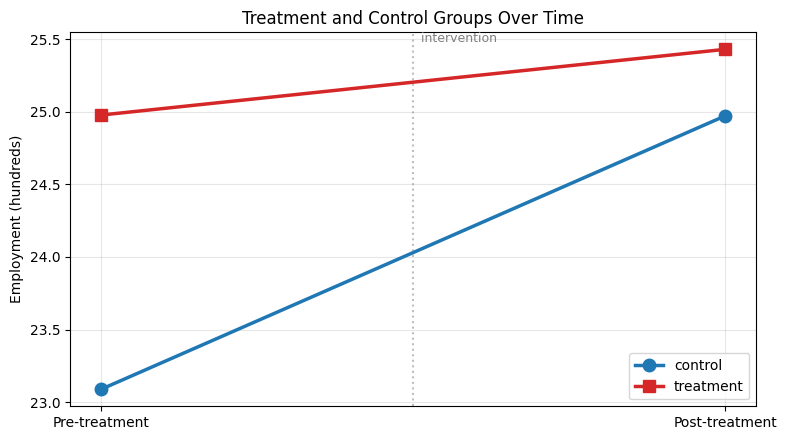

In [9]:
def make_did_data(n_units=200, true_effect=-1.5, seed=42):
    """Create a simple two-period, two-group panel dataset.

    Parameters
    ----------
    n_units : int
        Total number of cities (half treated, half control).
    true_effect : float
        The true causal effect of the treatment on the outcome.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    df : pd.DataFrame
        Columns: city, group, period, treated, employment.
    """
    rng = np.random.default_rng(seed)
    half = n_units // 2

    rows = []
    for i in range(n_units):
        group = "treatment" if i < half else "control"
        # Treatment cities start with slightly higher baseline employment
        baseline = 25.0 if group == "treatment" else 23.0
        time_trend = 2.0  # shared upward trend for both groups

        # Pre-treatment period (period=0)
        y_pre = baseline + rng.normal(0, 1.5)
        rows.append({
            "city": i, "group": group, "period": 0,
            "post": 0, "treat": int(group == "treatment"),
            "employment": y_pre,
        })

        # Post-treatment period (period=1)
        effect = true_effect if group == "treatment" else 0.0
        y_post = baseline + time_trend + effect + rng.normal(0, 1.5)
        rows.append({
            "city": i, "group": group, "period": 1,
            "post": 1, "treat": int(group == "treatment"),
            "employment": y_post,
        })

    return pd.DataFrame(rows)


TRUE_EFFECT = -1.5
df = make_did_data(true_effect=TRUE_EFFECT)
df.head(8)

# visualize the data
fig, ax = plt.subplots(figsize=(8, 4.5))

for grp, color, marker in [
    ("control", "#1f77b4", "o"),
    ("treatment", "#d62728", "s")
]:
    vals = means.loc[grp]
    ax.plot(
        [0, 1],
        [vals["pre"], vals["post"]],
        color=color,
        marker=marker,
        markersize=9,
        linewidth=2.5,
        label=grp
    )

ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.text(
    0.5,
    ax.get_ylim()[1],
    "  intervention",
    fontsize=9,
    color="gray",
    va="top"
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre-treatment", "Post-treatment"])
ax.set_ylabel("Employment (hundreds)")
ax.set_title("Treatment and Control Groups Over Time")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()

## 2. Group means table

The DiD estimate equals:

$$\hat{\delta}_{\text{DiD}} = (\bar{Y}_{\text{treat,post}} - \bar{Y}_{\text{treat,pre}}) - (\bar{Y}_{\text{ctrl,post}} - \bar{Y}_{\text{ctrl,pre}})$$

In [ ]:
means = df.groupby(["group", "period"])["employment"].mean().unstack()
means.columns = ["pre", "post"]
means["change"] = means["post"] - means["pre"]
print(means.round(3))

did_manual = means.loc["treatment", "change"] - means.loc["control", "change"]
print(f"\nManual DiD estimate: {did_manual:.3f}  (true effect: {TRUE_EFFECT})")


              pre    post  change
group                            
control    23.088  24.972   1.884
treatment  24.978  25.431   0.453

Manual DiD estimate: -1.431  (true effect: -1.5)


## 3. Visualize the parallel-trends idea

The dashed line shows where the treatment group *would have been* without the intervention (the counterfactual).

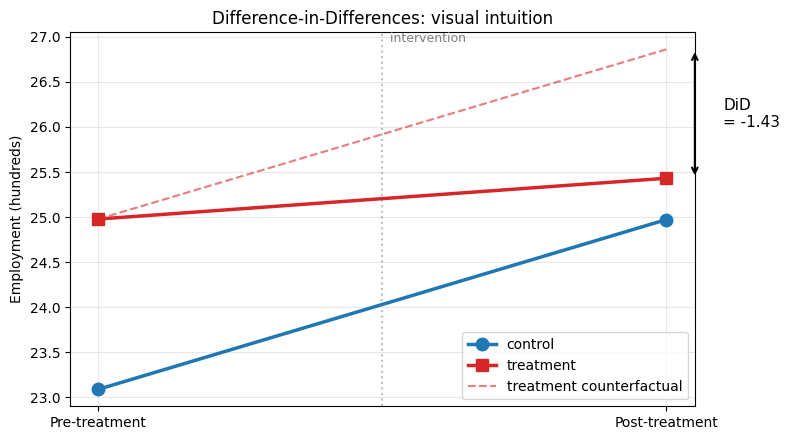

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for grp, color, marker in [("control", "#1f77b4", "o"), ("treatment", "#d62728", "s")]:
    vals = means.loc[grp]
    ax.plot([0, 1], [vals["pre"], vals["post"]], color=color, marker=marker,
            markersize=9, linewidth=2.5, label=grp)

# Counterfactual for treatment group (parallel to control trend)
counterfactual_post = means.loc["treatment", "pre"] + means.loc["control", "change"]
ax.plot([0, 1], [means.loc["treatment", "pre"], counterfactual_post],
        color="#d62728", linestyle="--", linewidth=1.5, alpha=0.6,
        label="treatment counterfactual")

# Annotate the causal effect
ax.annotate("", xy=(1.05, means.loc["treatment", "post"]),
            xytext=(1.05, counterfactual_post),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text(1.10, (means.loc["treatment", "post"] + counterfactual_post) / 2,
        f"DiD\n= {did_manual:.2f}", va="center", fontsize=11)

ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.text(0.5, ax.get_ylim()[1], "  intervention", fontsize=9, color="gray", va="top")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre-treatment", "Post-treatment"])
ax.set_ylabel("Employment (hundreds)")
ax.set_title("Difference-in-Differences: visual intuition")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()